Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import pickle
import xgboost as xgb
from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score,
    classification_report,
    f1_score
)

In [2]:
#train_df = pd.read_parquet("/content/drive/MyDrive/SB/SB_Project/classification_ring/data/processed/train.parquet")
train_df = pd.read_parquet('./classification_ring/data/processed/train.parquet')
#val_df = pd.read_parquet("/content/drive/MyDrive/SB/SB_Project/classification_ring/data/processed/val.parquet")
val_df = pd.read_parquet('./classification_ring/data/processed/val.parquet')

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']
target_names = label_cols

num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5'
]

cat_features = ['s_ss8', 's_3di_letter', 't_ss8', 't_3di_letter']
feature_cols = num_features + cat_features

X_train = train_df[feature_cols]
Y_train = train_df[label_cols]
X_val = val_df[feature_cols]
Y_val = val_df[label_cols]


In [3]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])


In [4]:
xgb_base = xgb.XGBClassifier(
    n_estimators=150,        # Number of boosting rounds
    max_depth=6,             # Maximum tree depth
    learning_rate=0.1,       # Step size shrinkage
    tree_method='hist',      # Optimized training method for large tabular datasets
    random_state=42,
    n_jobs=-1                # Use all available CPU cores
)

xgb_model = MultiOutputClassifier(xgb_base)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
], verbose=True)

print("XGBoost Pipeline built successfully.")

XGBoost Pipeline built successfully.


Training

In [6]:
train_model_bool = True  # Toggle to True to perform training
save_model_bool = True

if train_model_bool:
    print("Training xgboost Pipeline...")
    xgb_pipeline.fit(X_train, Y_train)
    print("Training complete!")

    if save_model_bool:
        os.makedirs("./classification_ring/models/xgboost", exist_ok=True)
        #os.makedirs("/content/drive/MyDrive/SB/SB_Project/classification_ring/models/xgboost", exist_ok=True)
        #model_path = "/content/drive/MyDrive/SB/SB_Project/classification_ring/models/xgboost/xgb_model.pkl"
        model_path = "./classification_ring/models/xgboost/xgb_model.pkl"
        with open(model_path, "wb") as f:
            pickle.dump(xgb_pipeline, f)
        print(f"Model saved to {model_path}")

Training xgboost Pipeline...
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   2.6s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  27.1s
Training complete!
Model saved to ./classification_ring/models/xgboost/xgb_model.pkl


In [8]:
def get_positive_class_scores(model, X):
    y_proba = model.predict_proba(X)
    if isinstance(y_proba, list):
        y_scores = np.column_stack([proba[:, 1] for proba in y_proba])
    else:
        y_scores = y_proba[:, 1]
    return y_scores

# Calculate predictions using validation thresholds
y_scores = get_positive_class_scores(xgb_pipeline, X_val)
# Compute all metrics and store them in dataframes



recompute_metrics_bool = True # Set to True so it runs!

if recompute_metrics_bool:
    print("Computing evaluation metrics for XGBoost...")
    target_names = label_cols

    # 1. We already have predicted probabilities (y_scores)
    thresholds = np.arange(0.00, 1.01, 0.01)

    threshold_results = []
    curve_results = []

    # 2. Compute metrics class by class
    for class_idx, class_name in enumerate(target_names):

        y_true = Y_val.iloc[:, class_idx].values
        y_score = y_scores[:, class_idx]

        # --------------------------------------------------------
        # Threshold-dependent metrics (MCC, Balanced Accuracy)
        # --------------------------------------------------------
        for threshold in thresholds:
            y_pred = (y_score >= threshold).astype(int)

            threshold_results.append({
                "class": class_name,
                "threshold": threshold,
                "MCC": matthews_corrcoef(y_true, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
            })

        # --------------------------------------------------------
        # Threshold-independent curve data (ROC, Precision-Recall)
        # --------------------------------------------------------
        precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
        fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)

        curve_results.append({
            "class": class_name,
            "precision": precision,
            "recall": recall,
            "pr_thresholds": pr_thresholds,
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,
            "average_precision": ap,
            "ROC_AUC": auc
        })

    # 3. Convert to DataFrames
    threshold_results_df = pd.DataFrame(threshold_results)
    curve_results_df = pd.DataFrame(curve_results)

    # 4. Save to files in the xgboost directory

    # --- Drive paths
    #os.makedirs("/content/drive/MyDrive/SB/SB_Project/classification_ring/models/xgboost/", exist_ok=True)
    #threshold_results_df.to_parquet("/content/drive/MyDrive/SB/SB_Project/classification_ring/models/xgboost/threshold_results.parquet", index=False)
    #curve_results_df.to_parquet("/content/drive/MyDrive/SB/SB_Project/classification_ring/models/xgboost/curve_results.parquet", index=False)

    # --- Local paths
    os.makedirs("./classification_ring/models/xgboost/", exist_ok=True)
    threshold_results_df.to_parquet("./classification_ring/models/xgboost/threshold_results.parquet", index=False)
    curve_results_df.to_parquet("./classification_ring/models/xgboost/curve_results.parquet", index=False)

    print("Metrics successfully calculated and saved to classification_ring/models/xgboost/")

Computing evaluation metrics for XGBoost...
Metrics successfully calculated and saved to classification_ring/models/xgboost/


In [9]:
best_thresholds_df = (
    threshold_results_df
    .sort_values(["class", "MCC"], ascending=[True, False])
    .groupby("class")
    .head(1)
    .reset_index(drop=True)
)

best_thresholds_df

,class,threshold,MCC,balanced_accuracy
0,HBOND,0.62,0.355173,0.657620
1,IONIC,0.20,0.585319,0.929255
2,PICATION,0.11,0.487814,0.927533
3,PIHBOND,0.01,0.085543,0.734182
4,PIPISTACK,0.35,0.856088,0.994262
5,SSBOND,0.52,0.908349,0.968635
6,VDW,0.51,0.197208,0.598297


In [10]:
curve_summary_df = curve_results_df[
    ["class", "average_precision", "ROC_AUC"]
]

curve_summary_df

,class,average_precision,ROC_AUC
0,HBOND,0.878993,0.752390
1,VDW,0.650893,0.644362
2,IONIC,0.562065,0.986574
3,PIPISTACK,0.847710,0.997201
4,PICATION,0.366625,0.992998
5,SSBOND,0.939031,0.999917
6,PIHBOND,0.016247,0.956601


In [11]:
# Extract feature importance rankings across estimators
fitted_preprocessor = xgb_pipeline.named_steps["preprocessor"]
transformed_names = fitted_preprocessor.get_feature_names_out()

# Inspect feature importance for the first interaction type (e.g., HBOND)
first_class_tree = xgb_pipeline.named_steps["classifier"].estimators_[0]
importances = first_class_tree.feature_importances_

importance_df = pd.DataFrame({
    "feature": transformed_names,
    "importance": importances
}).sort_values("importance", ascending=False)
print(importance_df.head(10))

                feature  importance
6             num__s_a4    0.056600
73  cat__t_3di_letter_T    0.050556
14            num__t_a4    0.047029
69  cat__t_3di_letter_P    0.037090
34  cat__s_3di_letter_J    0.035350
43  cat__s_3di_letter_S    0.031359
12            num__t_a2    0.029813
33  cat__s_3di_letter_I    0.025283
57  cat__t_3di_letter_D    0.023567
44  cat__s_3di_letter_T    0.023352


Plots

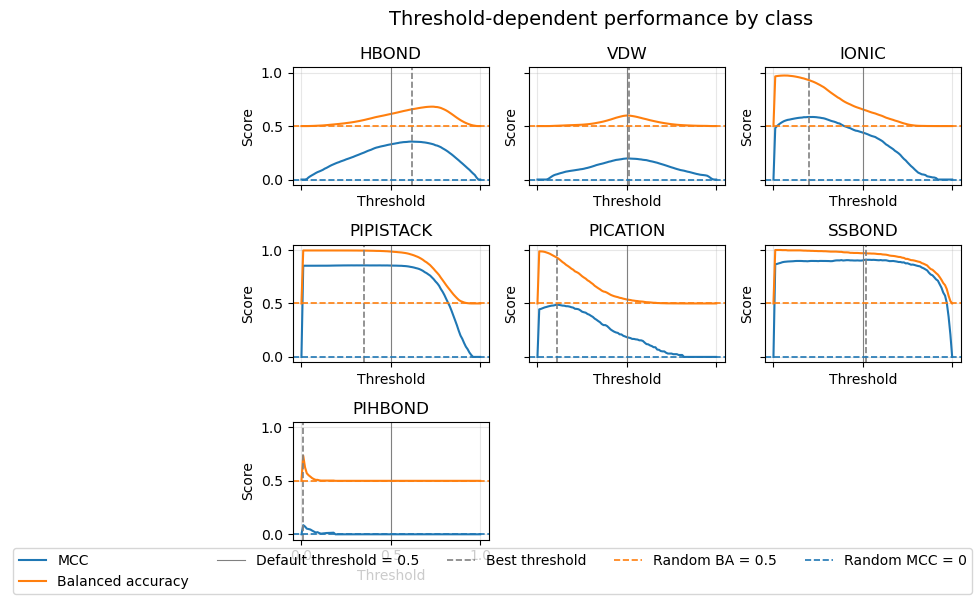

In [12]:

n_classes = len(target_names)
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.5 * n_cols, 2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    class_results = threshold_results_df[
        threshold_results_df["class"] == class_name
    ]

    ax.plot(
        class_results["threshold"],
        class_results["MCC"],
        label="MCC"
    )

    ax.plot(
        class_results["threshold"],
        class_results["balanced_accuracy"],
        label="Balanced accuracy"
    )

    ax.axvline(
        x=0.5,
        color="grey",
        lw=0.8,
        ls="solid",
        label="Default threshold = 0.5"
    )

    ax.axvline(
        x=best_thresholds_df.loc[best_thresholds_df["class"] == class_name, "threshold"].values[0],
        color="grey",
        lw=1.2,
        ls="dashed",
        label="Best threshold"
    )

    ax.axhline(
        y=0.5,
        color="tab:orange",
        lw=1.2,
        ls="dashed",
        label="Random BA = 0.5"
    )

    ax.axhline(
        y=0.0,
        color="tab:blue",
        lw=1.2,
        ls="dashed",
        label="Random MCC = 0"
    )



    ax.set_title(class_name)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.grid(alpha=0.3)

# Switch off unused axes
for ax in axes[n_classes:]:
    ax.axis("off")

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower right",
    ncol=5,
    frameon=True
)

fig.suptitle(
    "Threshold-dependent performance by class",
    fontsize=14
)

plt.tight_layout()
plt.show()

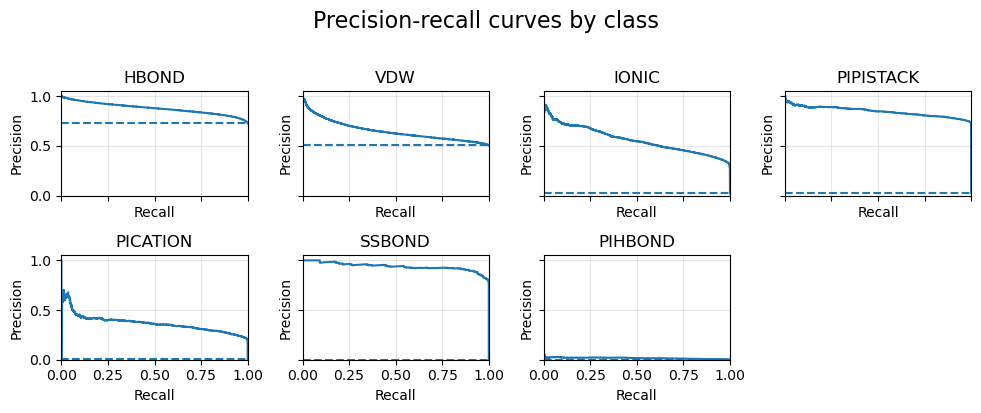

In [13]:

n_classes = len(target_names)

n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.5 * n_cols, 2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    row = curve_results_df[
        curve_results_df["class"] == class_name
    ].iloc[0]

    precision = row["precision"]
    recall = row["recall"]
    ap = row["average_precision"]

    # baseline = prevalence of the positive class
    y_true_class = (
        Y_val.iloc[:, class_idx].values
        if hasattr(Y_val, "iloc")
        else Y_val[:, class_idx]
    )
    prevalence = np.mean(y_true_class)

    ax.plot(
        recall,
        precision,
        label=f"PR curve, AP = {ap:.3f}"
    )

    ax.axhline(
        prevalence,
        linestyle="--",
        label=f"Random baseline = {prevalence:.3f}"
    )


    ax.set_title(class_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

# remove empty panels
for ax in axes[n_classes:]:
    ax.axis("off")




fig.suptitle(
    "Precision-recall curves by class",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

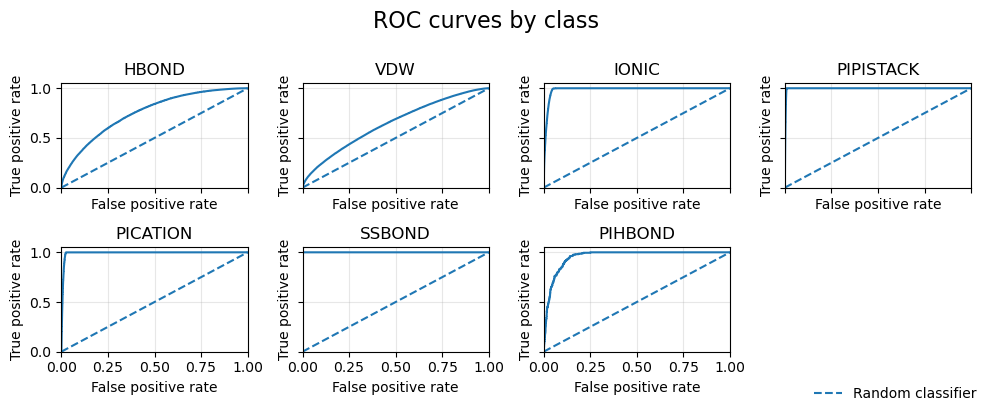

In [14]:
n_classes = len(target_names)

n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.5 * n_cols, 2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    row = curve_results_df[
        curve_results_df["class"] == class_name
    ].iloc[0]

    ax.plot(
        row["fpr"],
        row["tpr"],
        #label=f"ROC curve, AUC = {row['ROC_AUC']:.3f}"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color = "tab:blue",
        label="Random classifier"
    )

    ax.set_title(class_name)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

# remove empty panels
for ax in axes[n_classes:]:
    ax.axis("off")

# shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower right",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "ROC curves by class",
    fontsize=16,
    y=1
)

plt.tight_layout()
plt.show()

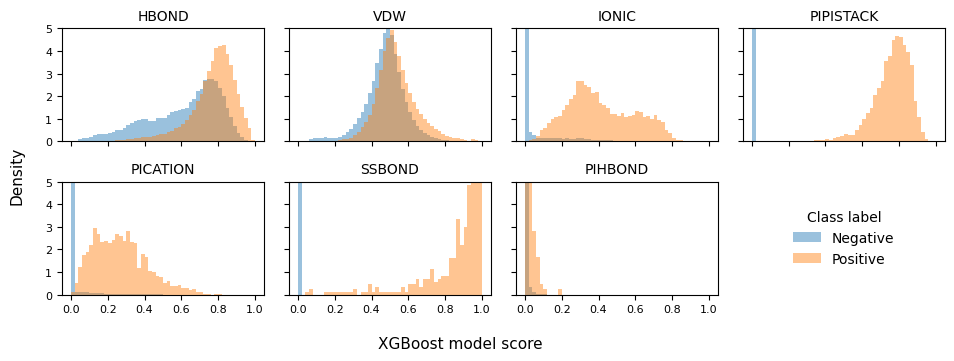

In [16]:

#Report-quality score-distribution fig

n_classes = len(target_names)
n_cols = len(target_names) // 2 + 1
n_rows = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 4.2),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

y_scores = get_positive_class_scores(xgb_pipeline, X_val)

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    y_true_class = (
        Y_val.iloc[:, class_idx]
        if hasattr(Y_val, "iloc")
        else Y_val[:, class_idx]
    )

    scores = y_scores[:, class_idx]

    positives = scores[y_true_class == 1]
    negatives = scores[y_true_class == 0]

    poscounts, posbins = np.histogram(
        positives,
        bins=50,
        range=(0, 1),
        density=True
    )

    negcounts, negbins = np.histogram(
        negatives,
        bins=50,
        range=(0, 1),
        density=True
    )

    ax.bar(
        negbins[:-1],
        negcounts,
        width=np.diff(negbins),
        label="Negative",
        alpha=0.45,
        align="edge"
    )

    ax.bar(
        posbins[:-1],
        poscounts,
        width=np.diff(posbins),
        label="Positive",
        alpha=0.45,
        align="edge"
    )

    ax.set_title(class_name, fontsize=10)
    ax.set_ylim(0, 5)
    ax.tick_params(axis="both", labelsize=8)


#Put legend in the unused bottom-right axis

legend_ax = axes[-1]
legend_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

legend_ax.legend(
    handles,
    labels,
    loc="center",
    frameon=False,
    fontsize=10,
    title="Class label",
    title_fontsize=10
)

fig.supxlabel(
    "XGBoost model score",
    fontsize=11,
    y=0.08
)

fig.supylabel(
    "Density",
    fontsize=11,
    x=0.05
)
fig.tight_layout(rect=[0.04, 0.06, 1.00, 0.93])

fig.savefig(
    "report_figures/xgboost_scores.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600
)

plt.show()

In [17]:

# Baseline prevalence of each label in the validation set
label_prevalence = Y_val.mean().sort_values(ascending=False)

# First row of final dataframe
prevalence_rows = {
    "baseline": label_prevalence
}

false_positive_counts = {}

Y_pred = xgb_pipeline.predict(X_val)

# Make sure Y_pred is a DataFrame with same columns/index as Y_val
Y_pred_df = pd.DataFrame(
    Y_pred,
    columns=Y_val.columns,
    index=Y_val.index
)

for class_idx, class_name in enumerate(target_names):

    # Samples predicted as class_name, but truly not class_name
    fp_mask = (Y_val.iloc[:, class_idx] == 0) & (Y_pred_df.iloc[:, class_idx] == 1)

    false_positives = Y_val.loc[fp_mask]

    n_fp = len(false_positives)
    false_positive_counts[class_name] = n_fp

    if n_fp == 0:
        print(f"\nNo false positives for {class_name}")
        continue

    # Drop the class itself, since it is necessarily 0 among its false positives
    false_positives_no_self = false_positives.drop(columns=[class_name])

    # Prevalence of true labels among false positives
    fp_label_prevalence = false_positives_no_self.mean()

    # Add as a row
    prevalence_rows[f"FP_{class_name}"] = fp_label_prevalence

# Final dataframe
fp_prevalence_df = pd.DataFrame(prevalence_rows).T

# Optional: inspect number of false positives per predicted class
false_positive_counts = pd.Series(false_positive_counts, name="n_false_positives")


display(fp_prevalence_df)
print(false_positive_counts)


No false positives for PIHBOND


,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
baseline,0.727294,0.022955,0.006277,0.000888,0.024530,0.001809,0.506566
FP_HBOND,NaN,0.009195,0.016876,0.002167,0.013004,0.000126,0.978243
FP_VDW,0.944600,0.030096,0.012777,0.001493,0.046668,0.003650,NaN
FP_IONIC,0.757000,NaN,0.000000,0.000000,0.000000,0.000000,0.516000
FP_PIPISTACK,0.597347,0.000000,0.000000,0.000000,NaN,0.000000,0.571883
FP_PICATION,0.364341,0.000000,NaN,0.000000,0.000000,0.000000,0.782946
FP_SSBOND,0.435484,0.000000,0.000000,0.000000,0.000000,NaN,0.741935


HBOND        47524
VDW          48213
IONIC         1000
PIPISTACK     1885
PICATION       129
SSBOND          62
PIHBOND          0
Name: n_false_positives, dtype: int64


In [18]:
enrichment_df = (fp_prevalence_df - fp_prevalence_df.loc["baseline"]) / fp_prevalence_df.loc["baseline"]
enrichment_df = enrichment_df.drop(index="baseline")  # Exclude the baseline row
enrichment_df = enrichment_df[[class_name for class_name in target_names]]


display(enrichment_df)

,HBOND,VDW,IONIC,PIPISTACK,PICATION,SSBOND,PIHBOND
FP_HBOND,NaN,0.931126,-0.599427,-0.469875,1.688514,-0.930208,1.441411
FP_VDW,0.298788,NaN,0.311042,0.902486,1.035483,1.017982,0.682229
FP_IONIC,0.040845,0.018624,NaN,-1.000000,-1.000000,-1.000000,-1.000000
FP_PIPISTACK,-0.178671,0.128942,-1.000000,NaN,-1.000000,-1.000000,-1.000000
FP_PICATION,-0.499045,0.545595,-1.000000,-1.000000,NaN,-1.000000,-1.000000
FP_SSBOND,-0.401227,0.464638,-1.000000,-1.000000,-1.000000,NaN,-1.000000


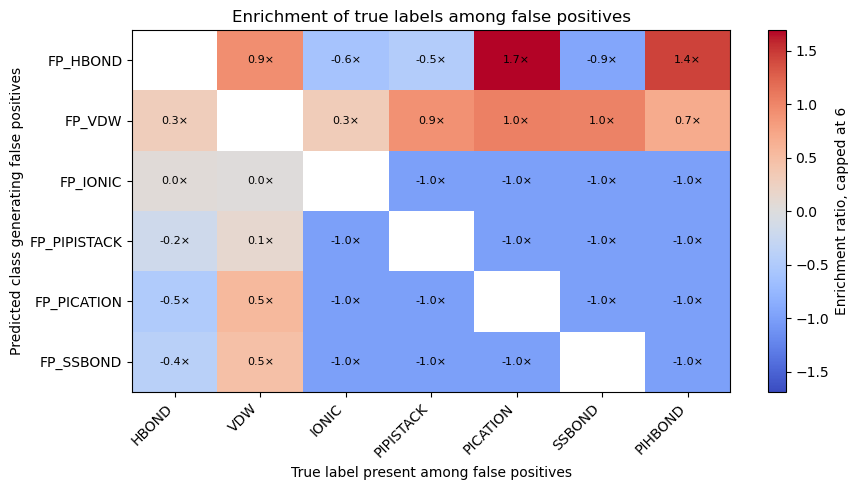

In [20]:
plot_df = enrichment_df.clip(upper=6)

fig, ax = plt.subplots(figsize=(9, 5))

import matplotlib.colors as mcolors

vmax = np.nanmax(np.abs(plot_df.values))
vmin = -vmax

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(
    plot_df,
    aspect="auto",
    cmap="coolwarm",
    norm=norm
)

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_yticks(np.arange(plot_df.shape[0]))

ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("True label present among false positives")
ax.set_ylabel("Predicted class generating false positives")
ax.set_title("Enrichment of true labels among false positives")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Enrichment ratio, capped at 6")

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        value = plot_df.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.1f}×", ha="center", va="center", fontsize=8)



plt.savefig(
    "report_figures/xgboost_false_positive_enrichment.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.tight_layout()
plt.show()